# Univariate forecasting with `numpyro_forecast`

Here we present an introduction to the `numpyro_forecast` package. This notebook ports the blog post [**Univariate time series forecasting with NumPyro**](https://juanitorduz.github.io/numpyro_forecasting-univariate/) (itself a port of Pyro's [forecasting tutorial](https://pyro.ai/examples/forecasting_i.html)) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. We forecast **weekly BART ridership** with a random-walk local level, Fourier seasonality and a Student-T likelihood, fit with stochastic variational inference (SVI), and evaluate with the continuous ranked probability score (CRPS).

Instead of hand-writing the NumPyro model and a bespoke prediction loop, we subclass `numpyro_forecast.forecaster.ForecastingModel` and let `Forecaster` handle the *fit-once / forecast-any-horizon* mechanics (the forecast horizon is drawn from separate `_future` latent sites, so the variational guide is never resized).

> **Note on reproducibility.** We match the blog's data, seed, optimizer and step counts. Results reproduce the blog's behavior and CRPS magnitude but are not bit-for-bit identical: the forecast horizon uses the package's separate-`_future`-site mechanism (rather than re-running the guide over the full covariates), and the seasonal design uses `fourier_features`, an equivalent Fourier basis.

## Prepare notebook

In [1]:
import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import Predictive
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import Forecaster, ForecastingModel, eval_crps
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.typing import Array
from numpyro_forecast.util import fourier_features

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We work with total **weekly** BART ridership: hourly counts summed over all origin-destination pairs and aggregated into non-overlapping weeks. The series grows roughly multiplicatively, so we model it on the log scale, where the trend and the seasonal swings are closer to additive. Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`, so a single series has shape `(weeks, 1)`.

data shape: (469, 1)


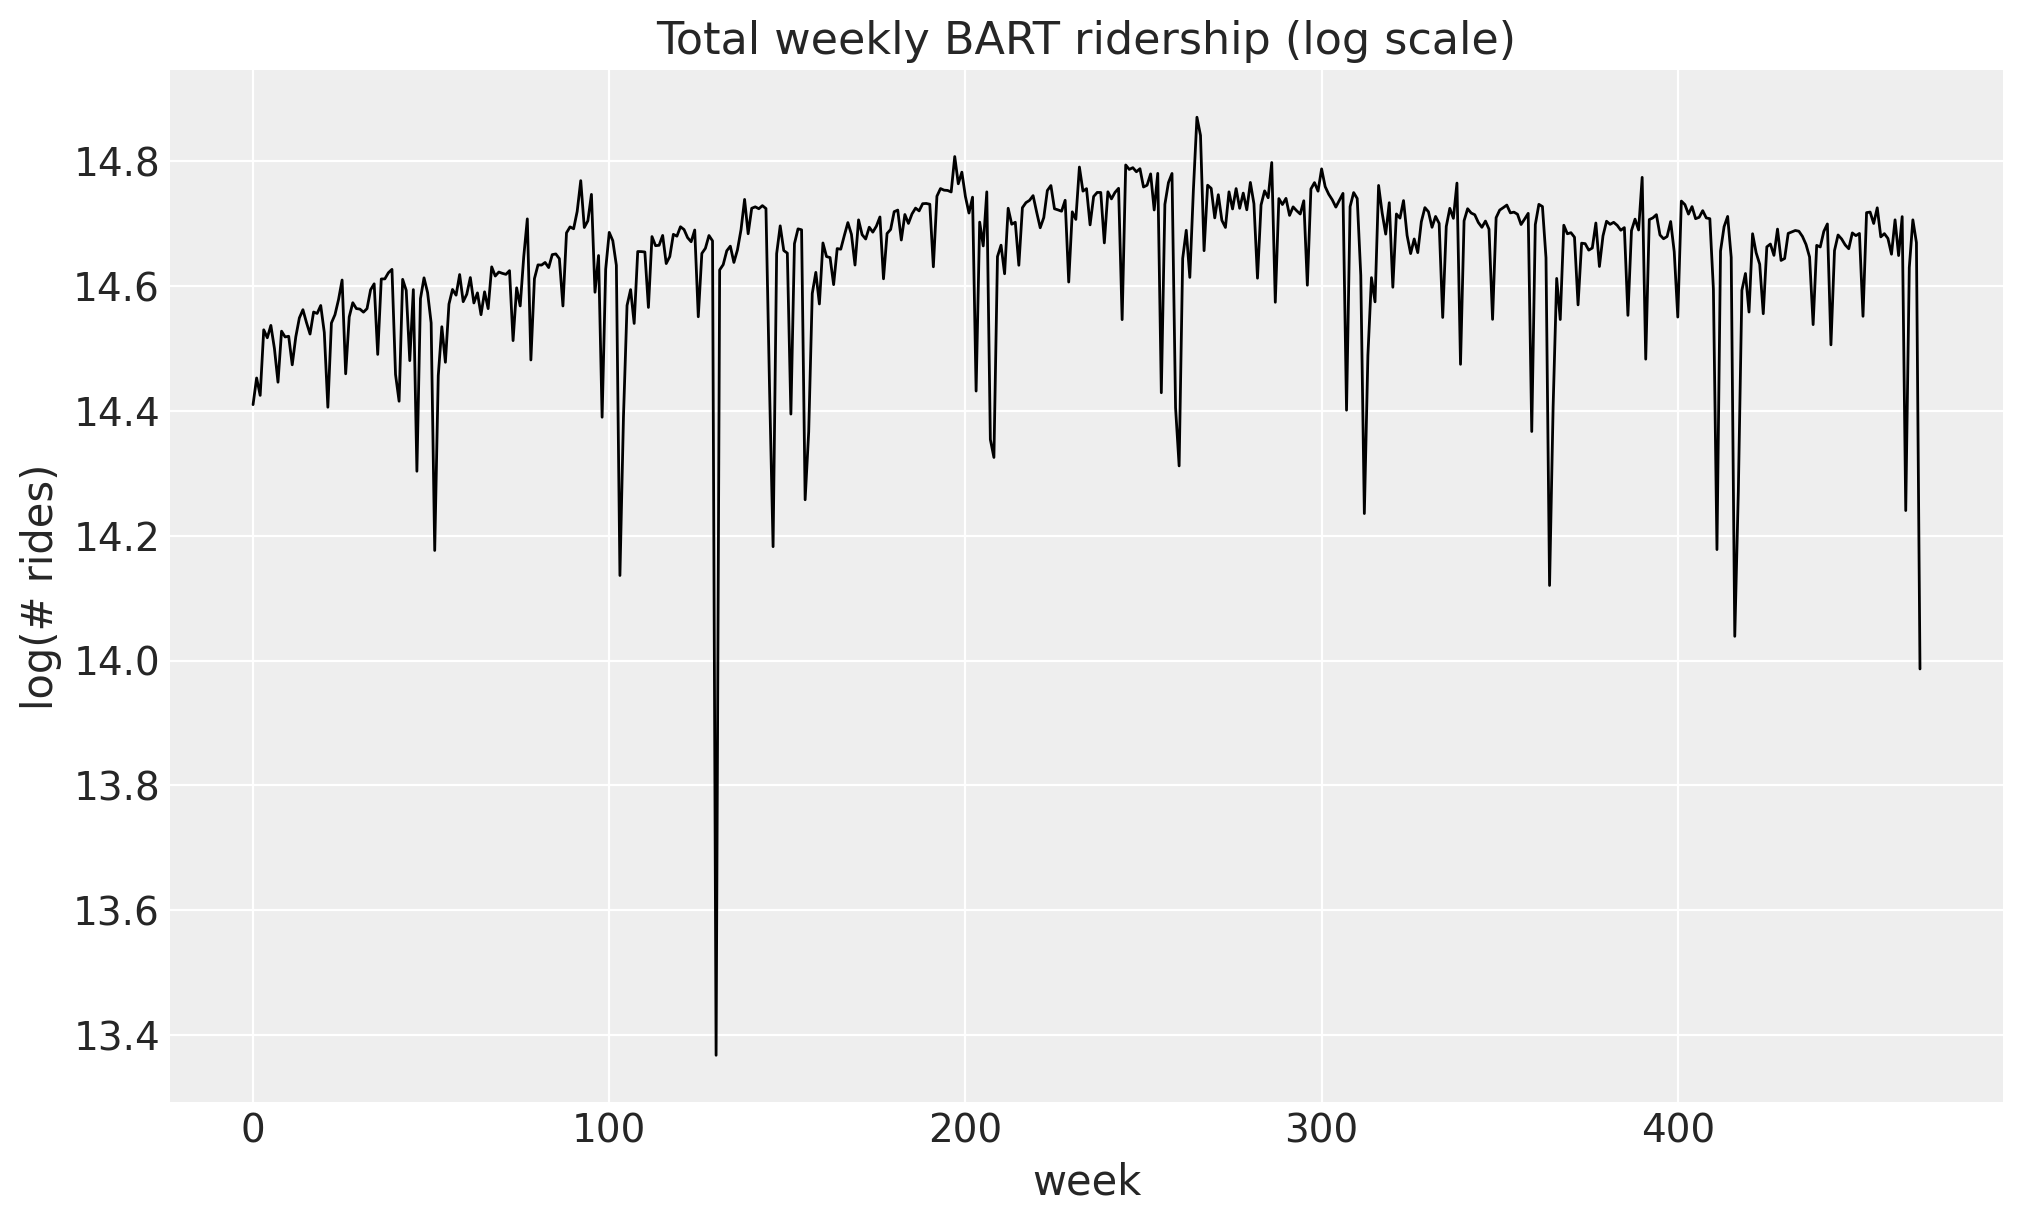

In [2]:
data = load_bart_weekly()  # (weeks, 1), log scale
duration = data.shape[0]
print("data shape:", data.shape)

fig, ax = plt.subplots()
ax.plot(np.asarray(data[:, 0]), color="black", lw=1)
ax.set(
    title="Total weekly BART ridership (log scale)",
    xlabel="week",
    ylabel="log(# rides)",
);

## Train-test split

We hold out the last `52` weeks (one full year) as the test set and train on the preceding `417` weeks. Keeping a whole year out means the test window covers a complete seasonal cycle, which is exactly where a seasonal model can over- or under-fit.

train: (417, 1) test: (52, 1)


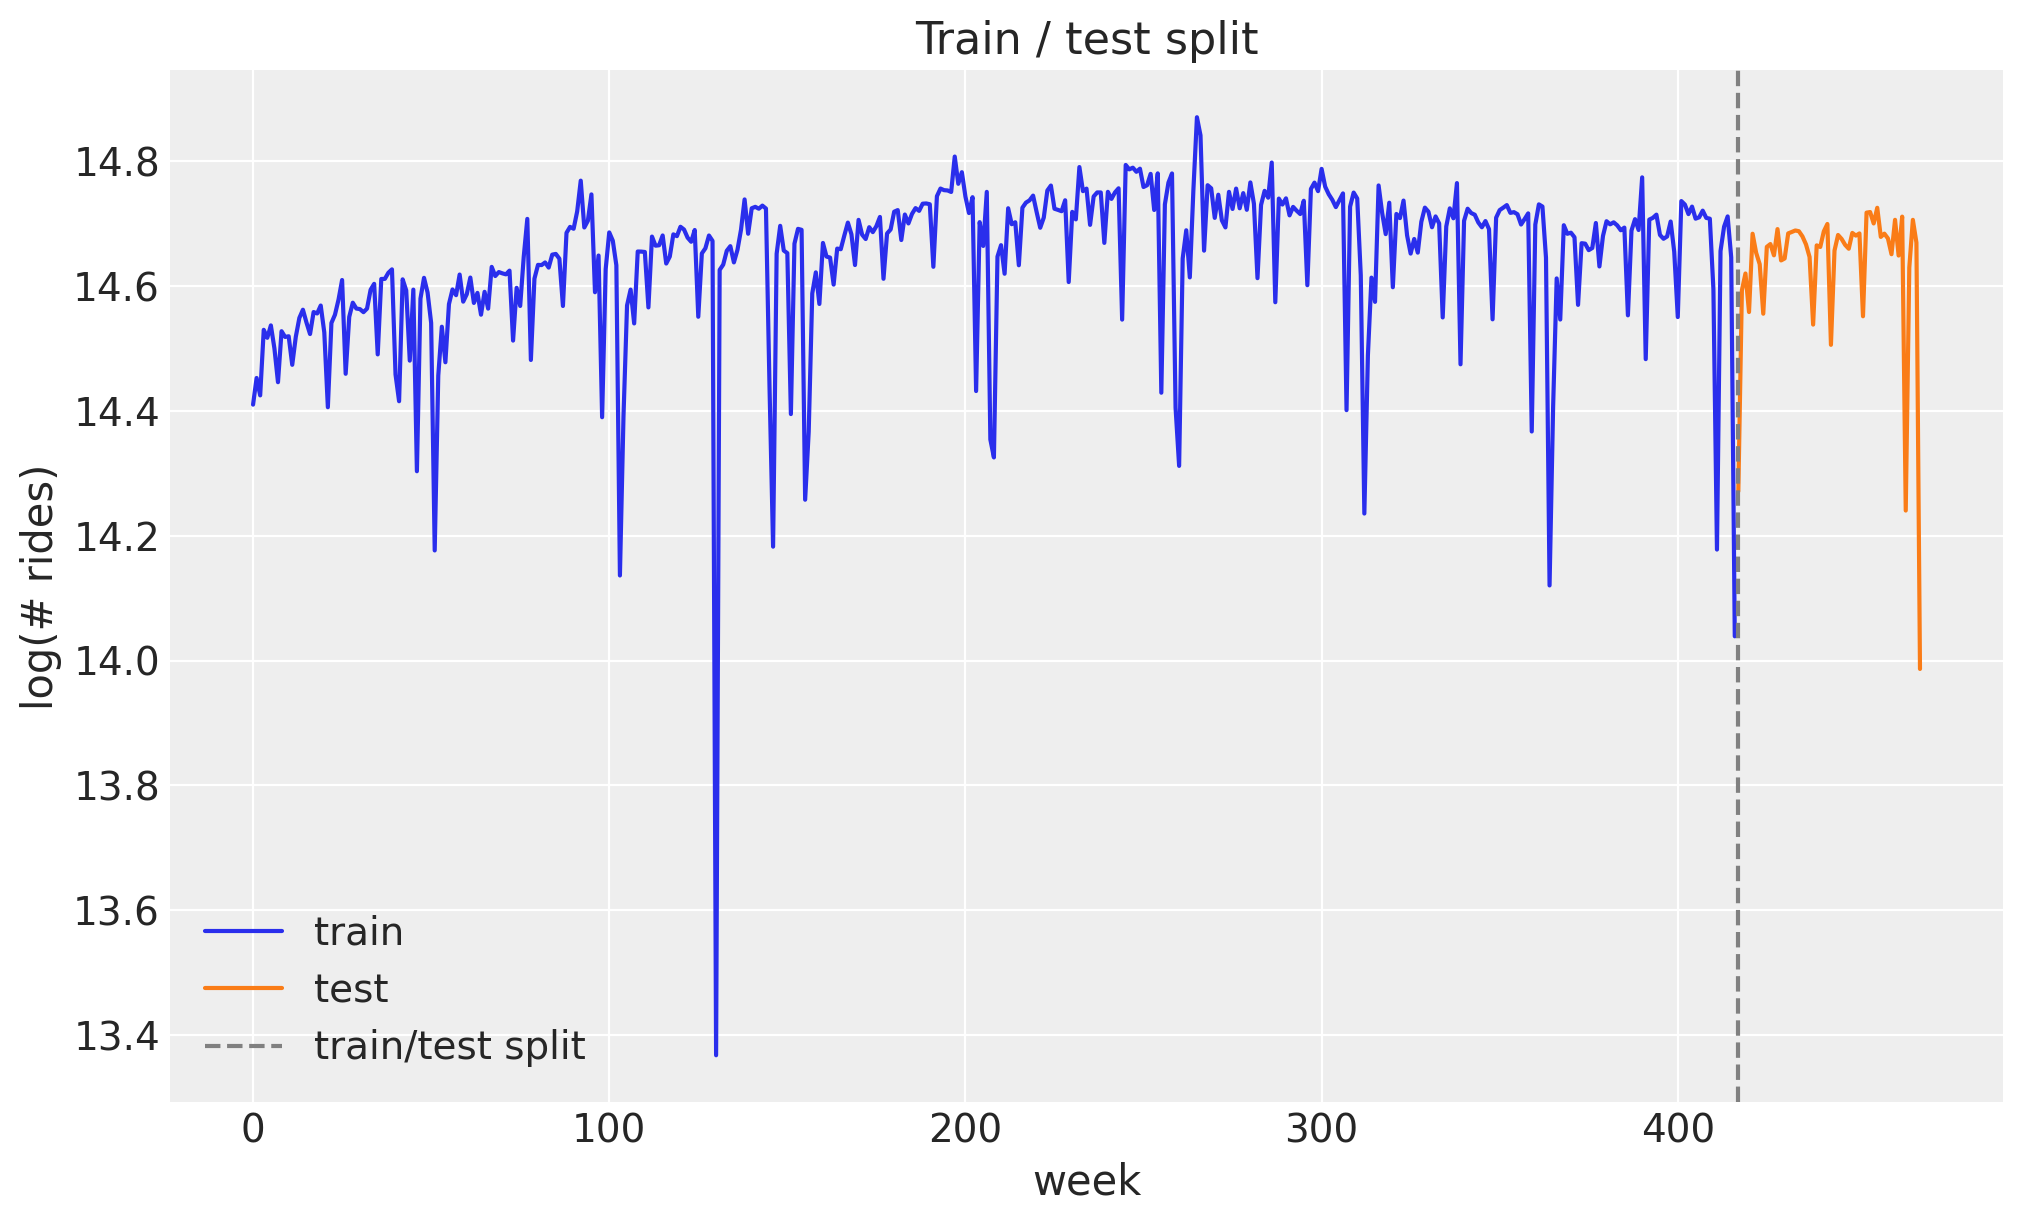

In [3]:
T0 = 0
T2 = duration  # 469
T1 = T2 - 52  # 417: train / test split

y_train = data[T0:T1]
y_test = data[T1:T2]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

fig, ax = plt.subplots()
ax.plot(time_train, np.asarray(y_train[:, 0]), color="C0", label="train")
ax.plot(time_test, np.asarray(y_test[:, 0]), color="C1", label="test")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)");

## Seasonal features

To capture the annual cycle we use a **Fourier** design matrix: `26` harmonics (so `52` sine and cosine columns) at a period of `365.25 / 7` weeks. Each harmonic is a sine/cosine pair at a multiple of the base frequency, and a weighted sum of them can approximate any smooth periodic shape. This spans the same subspace as the blog's `periodic_features`, so paired with the `Normal(0, 0.1)` weight prior the regression is equivalent. The plot below shows the first few low-frequency modes.

covariates shape: (469, 52)


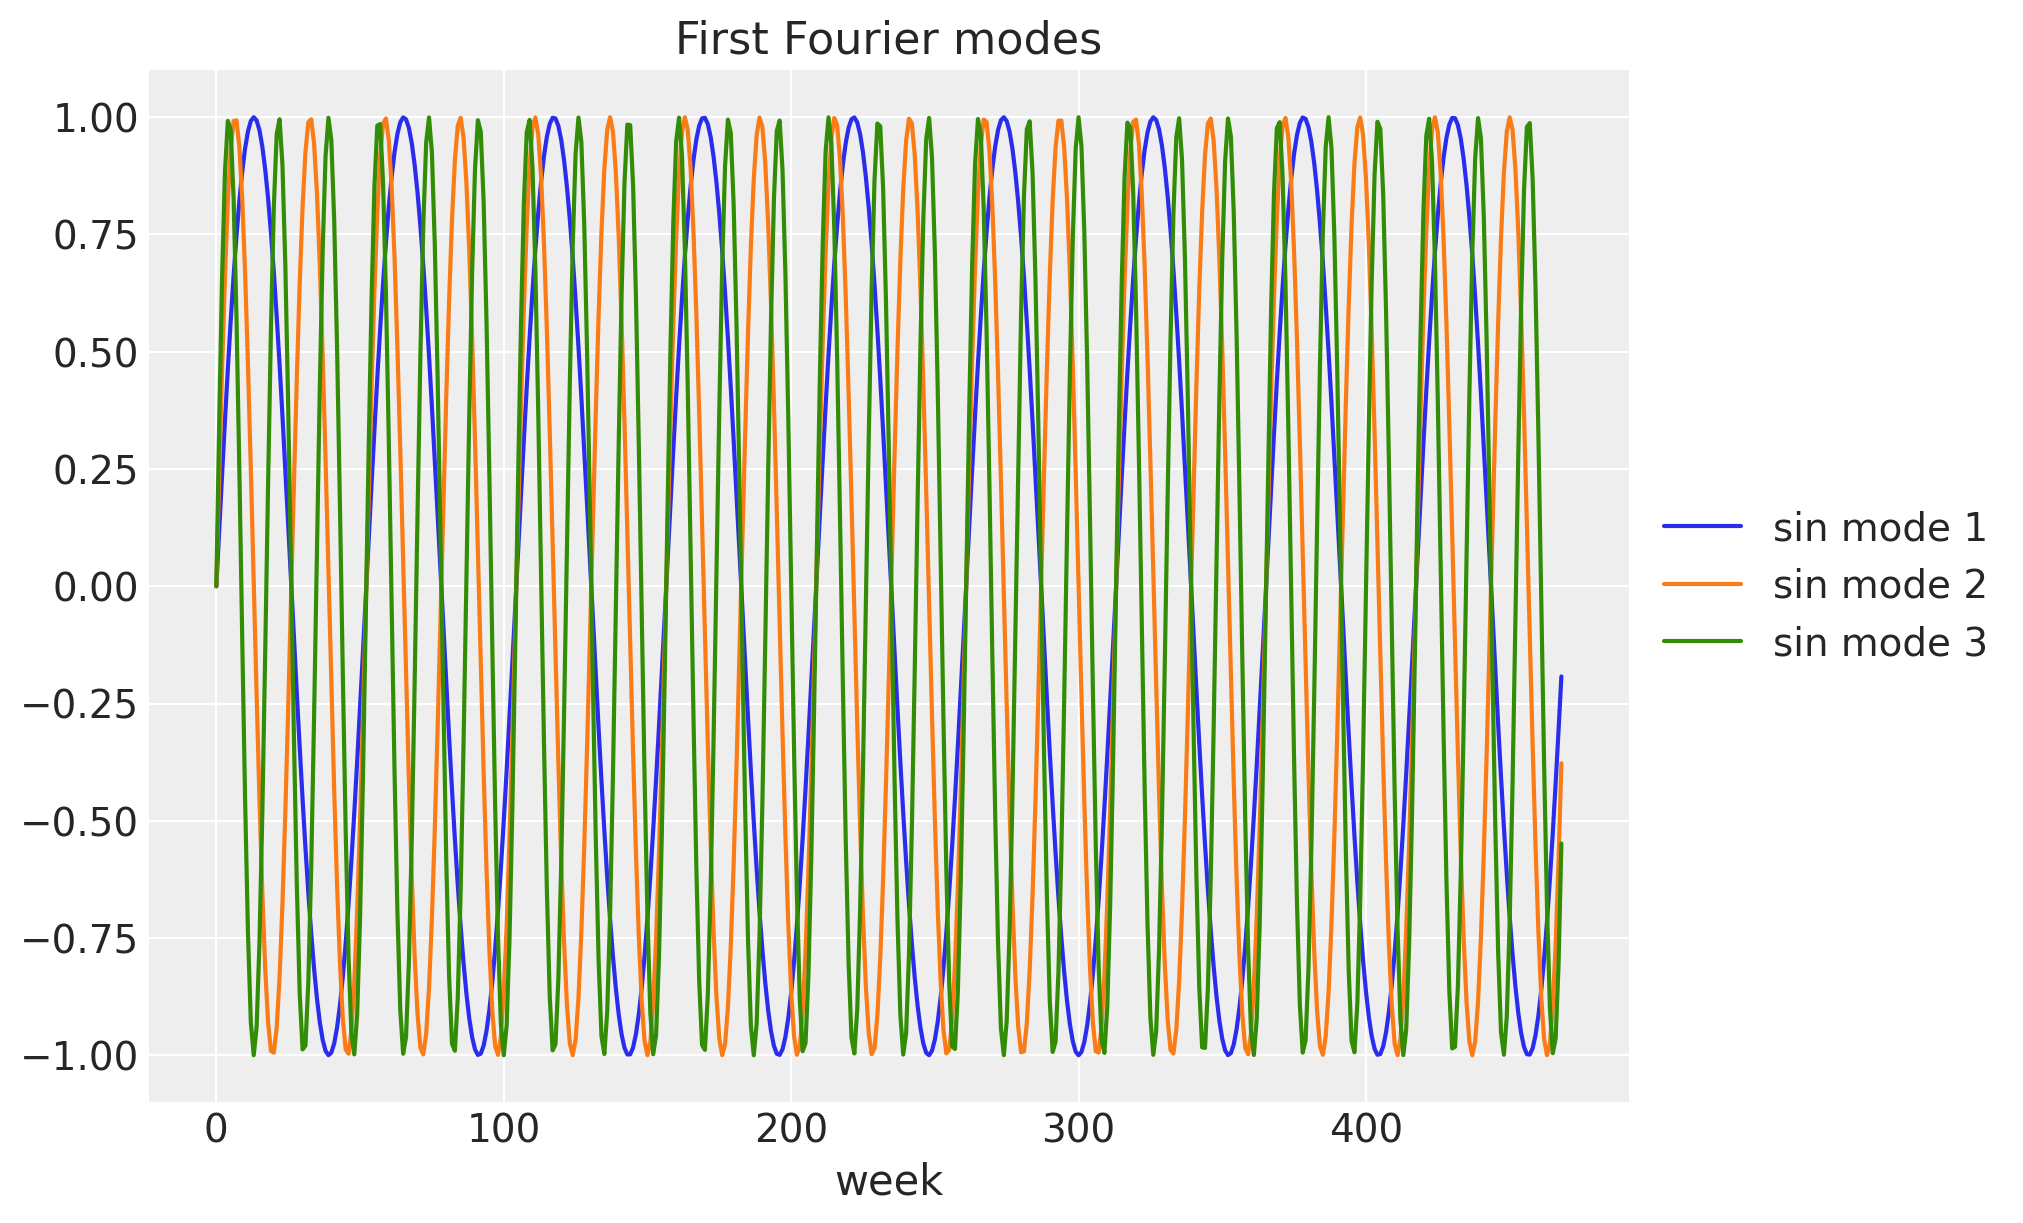

In [4]:
num_terms = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=num_terms)
covariates_train = covariates[T0:T1]
print("covariates shape:", covariates.shape)

fig, ax = plt.subplots()
for k in range(3):
    ax.plot(np.asarray(covariates[:, k]), label=f"sin mode {k + 1}")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="First Fourier modes", xlabel="week");

## Model specification

The idea is a *local level model with seasonality*. The mean has three parts: a global `bias`, a random-walk level $\ell_t$ that lets the baseline drift slowly over time, and a Fourier regression for the annual cycle. The level moves by small Gaussian increments (the `drift`), so it can follow long-term changes without being told their shape in advance. For the likelihood we use a Student-T instead of a Normal: its heavy tails make the model robust to the occasional outlier week.

\begin{align*}
\mu_t  & = \text{bias} + \ell_t + w^\top x_t, \\
\ell_t & = \ell_{t-1} + \delta_t, \\
\delta_t & \sim \text{Normal}(0, \sigma_\text{drift}), \\
y_t & \sim \text{StudentT}(\nu, \mu_t, \sigma).
\end{align*}

We subclass `ForecastingModel` and write the generative story in `model`. The level is the cumulative sum of `drift`, which we sample with `self.time_series(...)` (the package's equivalent of the blog's `scan` over time). The single call to `self.predict(...)` registers the zero-centered Student-T noise around the predicted mean, and it is also what wires up the train-vs-forecast machinery: in-sample steps are observed, while the forecast horizon is drawn from separate `_future` latent sites so the variational guide never changes shape. Finally, a `LocScaleReparam` on the drift switches between centered and non-centered parameterizations, which helps the SVI geometry quite a lot.

In [5]:
class UnivariateForecaster(ForecastingModel):
    """Local level + Fourier regression with Student-T observations."""

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the univariate forecasting model."""
        num_features = covariates.shape[-1]

        bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
        weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
        nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
        sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
        centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

        drift = self.time_series(
            "drift",
            lambda: dist.Normal(0.0, drift_scale),
            reparam=LocScaleReparam(centered=centered),
        )
        level = jnp.cumsum(drift, axis=-2)
        regression = (weight * covariates).sum(axis=-1, keepdims=True)
        prediction = level + bias + regression

        self.predict(dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)

Let's visualize the model:

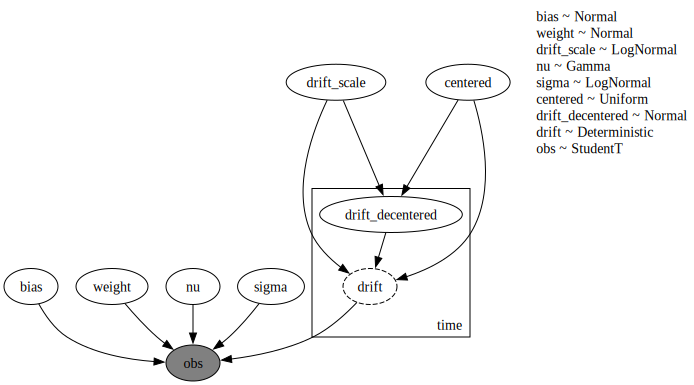

In [6]:
numpyro.render_model(
    UnivariateForecaster(),
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

As usual (highly recommended!), we look at the prior predictive before fitting anything. We draw from the prior over the training window (`data=None`, so the horizon is zero and the `obs` site spans the train period) and plot the 50% and 94% HDI bands against the training series with ArviZ `plot_lm`. The priors are not very informative, but the implied ranges sit comfortably around the data, which is what we want.

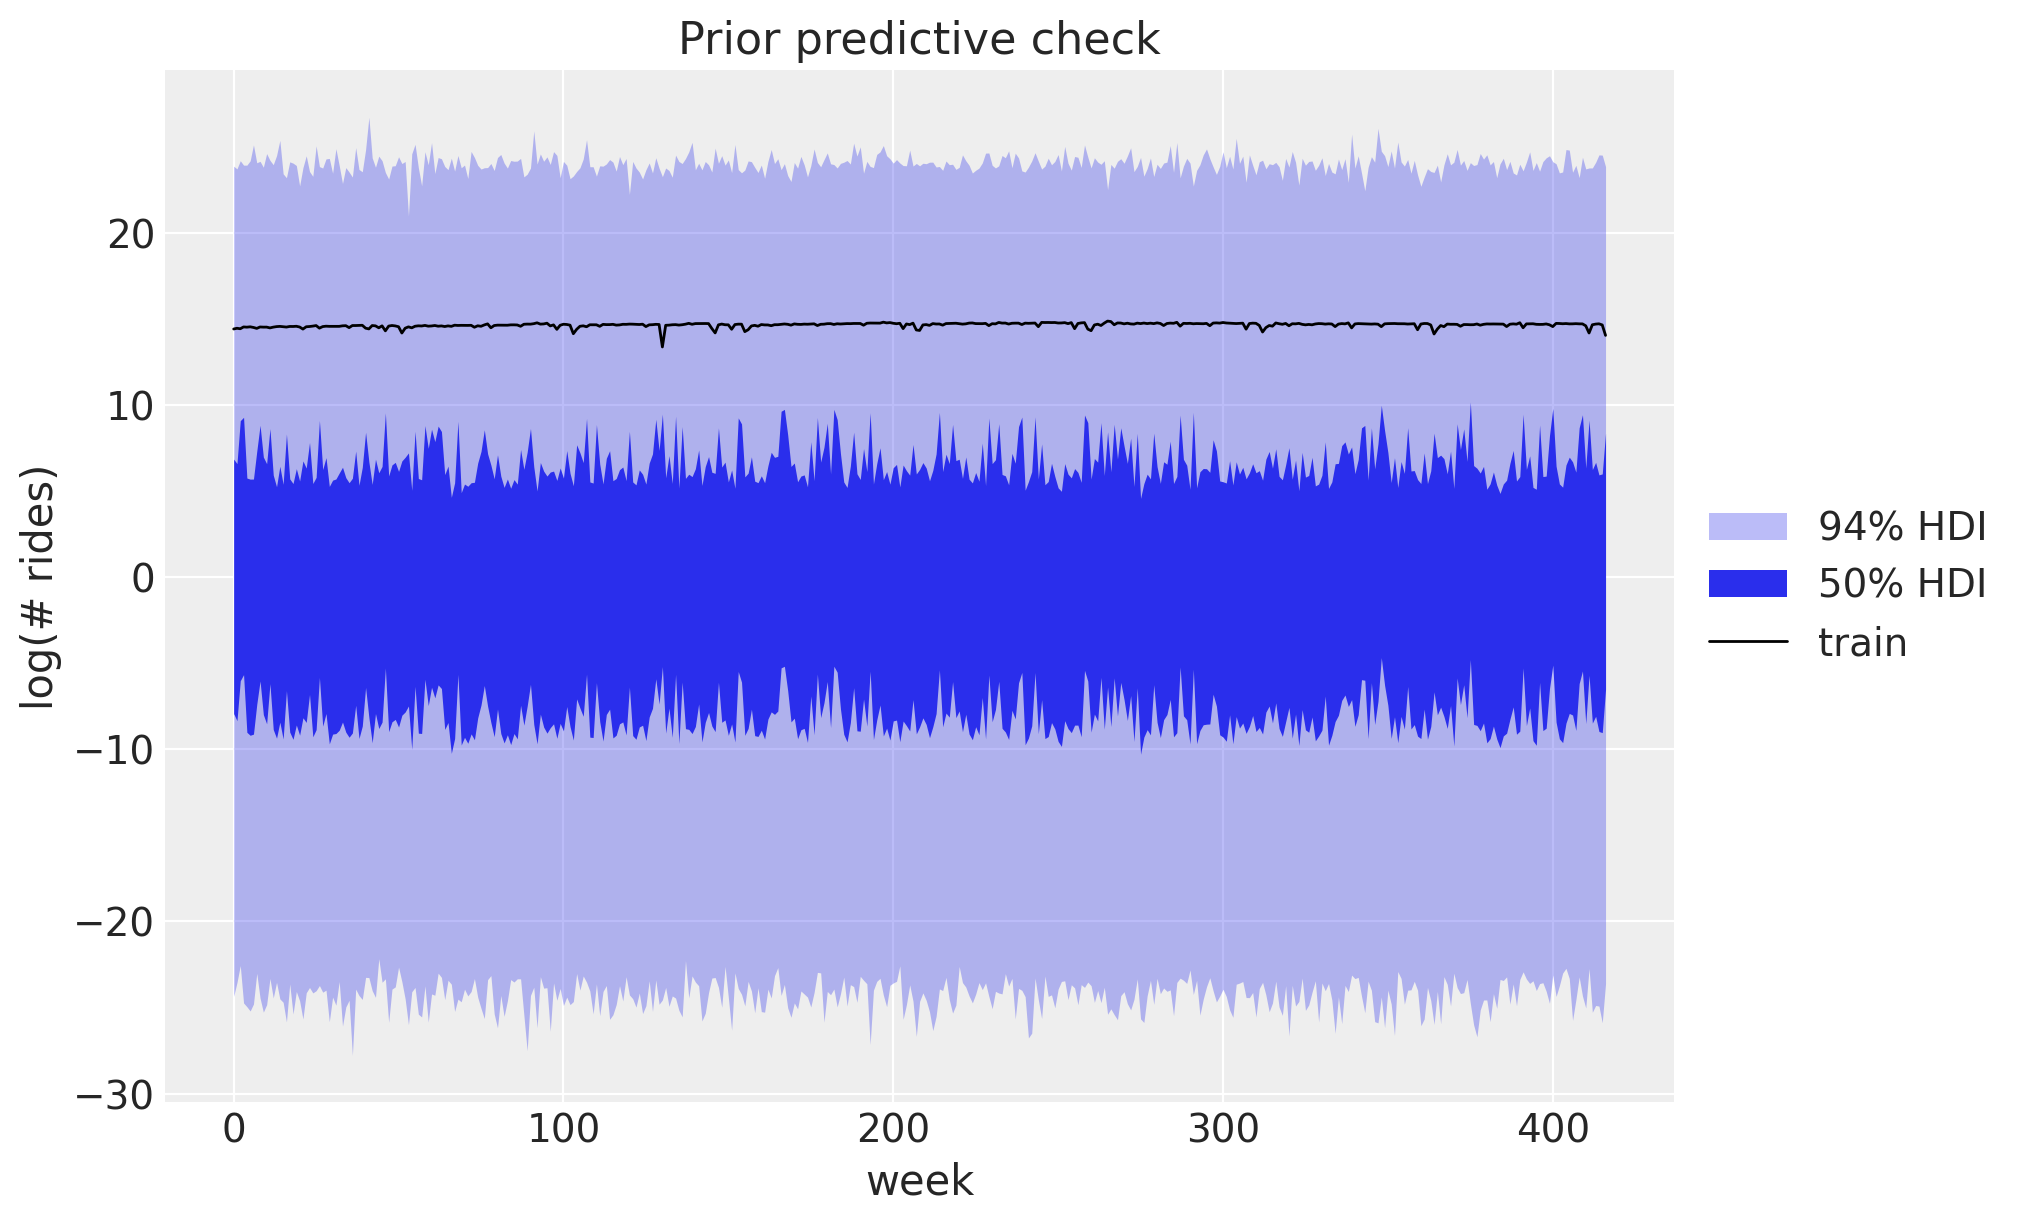

In [7]:
prior_predictive = Predictive(UnivariateForecaster(), num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"][..., 0]

idata_prior = az.from_dict(
    {
        "prior_predictive": {"obs": np.asarray(prior_obs)[None]},
        "observed_data": {"obs": np.asarray(y_train[:, 0])},
        "constant_data": {"week": time_train.astype(float)},
    },
    coords={"time": time_train.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
pc = az.plot_lm(
    idata_prior,
    y="obs",
    x="week",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.viz["figure"].item().axes[0]
band_50, band_94 = ax.collections  # in ci_prob order: (0.5, 0.94)
band_50.set_label("50% HDI")
band_94.set_label("94% HDI")
(train_line,) = ax.plot(time_train, np.asarray(y_train[:, 0]), color="black", lw=1, label="train")
ax.legend(handles=[band_94, band_50, train_line], loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Prior predictive check", ylabel="log(# rides)");

## Inference with SVI

We fit the model with stochastic variational inference. Passing the model and data to `Forecaster` runs SVI under the hood (an `AutoNormal` guide with `Adam`) and stores the fitted `guide`, `params` and the ELBO `losses`. The loss curve should decrease and flatten out, a quick sanity check that the optimization converged.

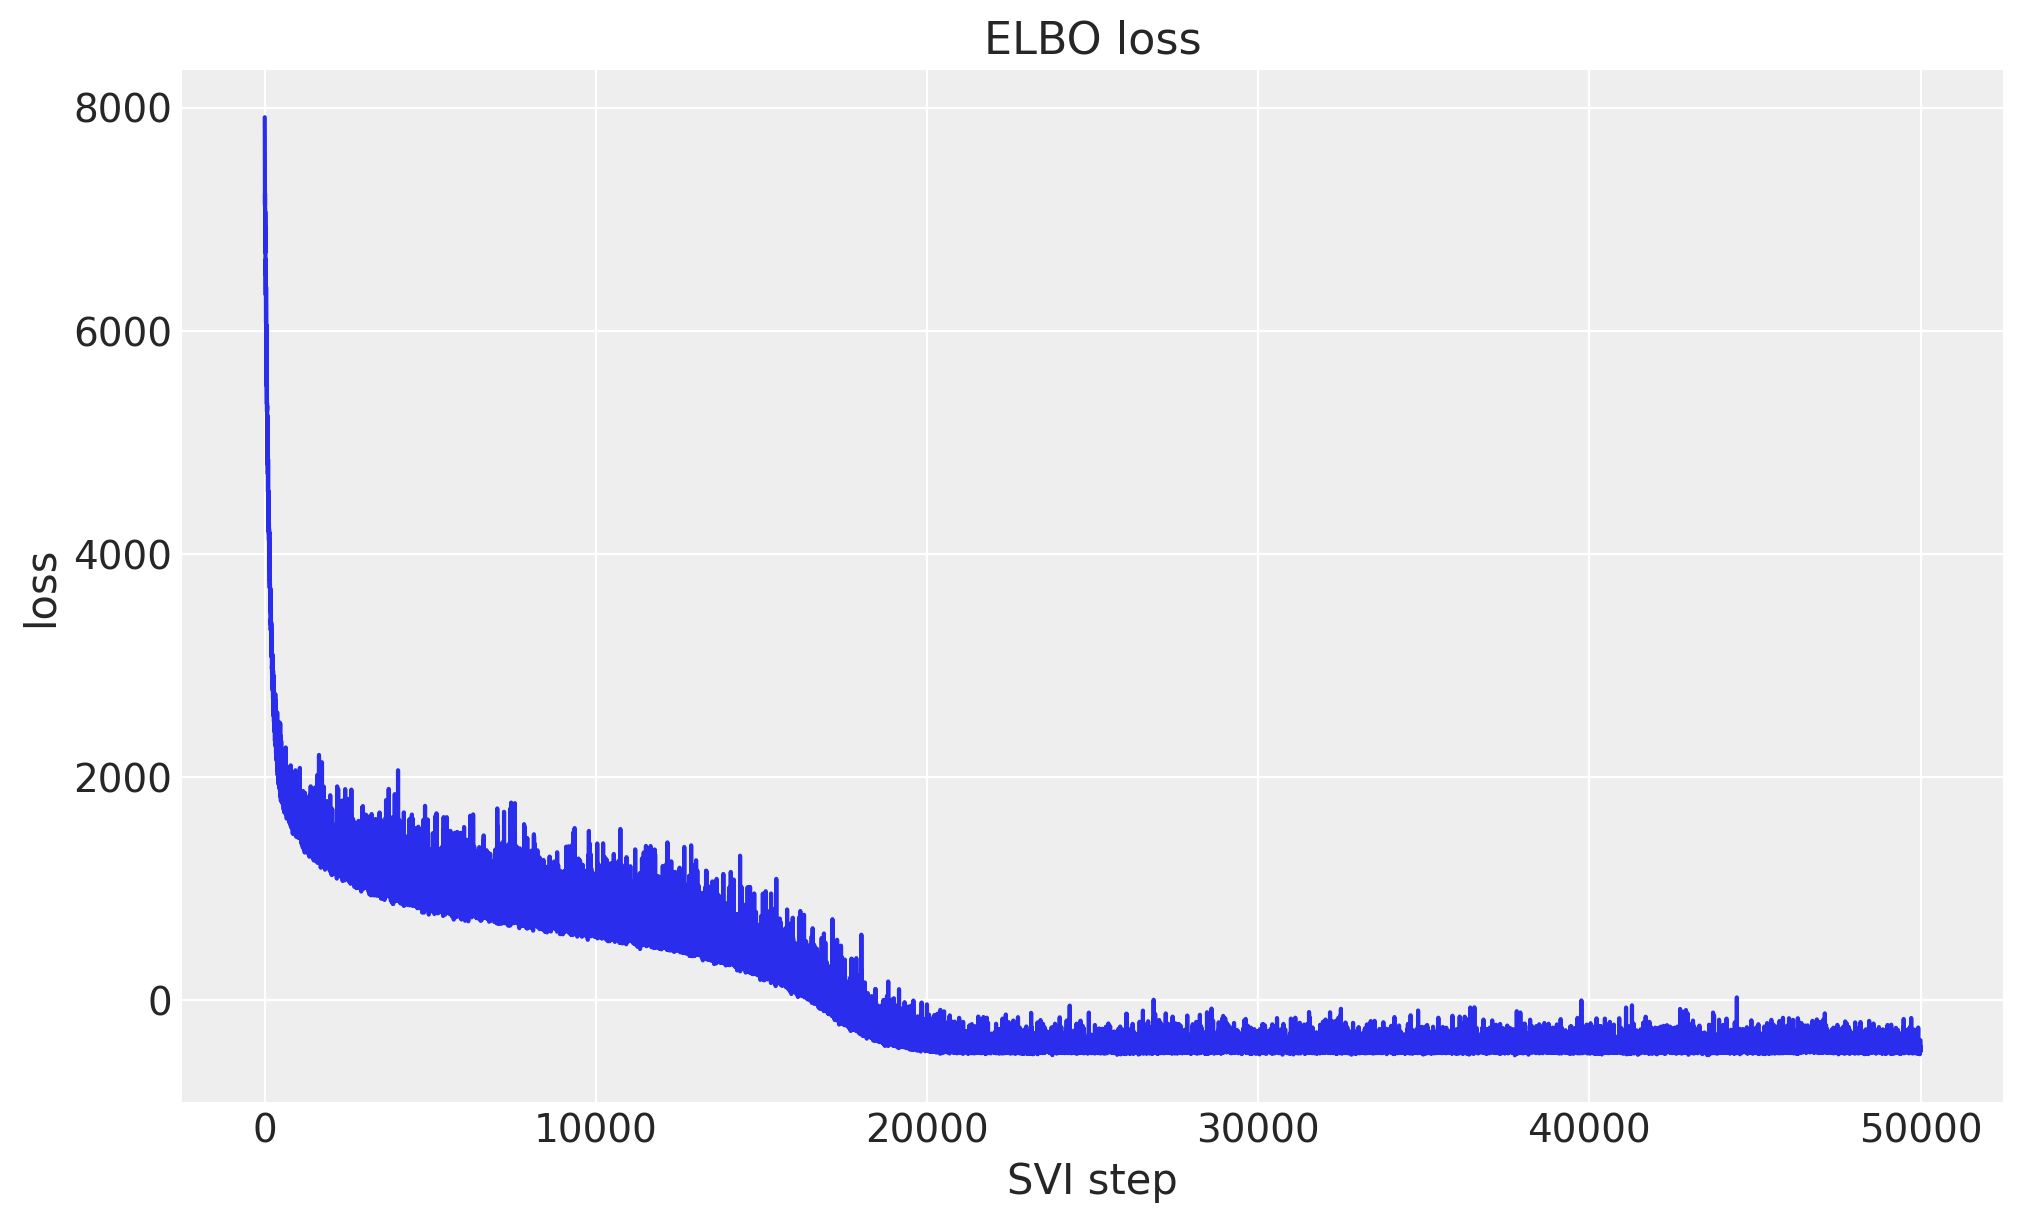

In [8]:
rng_key, rng_subkey = random.split(rng_key)
model = UnivariateForecaster()
forecaster = Forecaster(
    rng_subkey,
    model,
    y_train,
    covariates_train,
    optim=Adam(step_size=0.005),
    num_steps=50_000,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

## Posterior predictive check

We now look at two things. First the **in-sample** posterior predictive over the training window: here the horizon is zero, so the guide is not resized and we just sample the `obs` site. Then the **forecast** over the test horizon with `forecaster(...)`, which continues the level from its inferred endpoint and draws the future random-walk increments from the prior.

To score both we use the **continuous ranked probability score** (CRPS), a proper scoring rule that compares a single ground-truth value to the whole forecast distribution rather than just a point estimate. It rewards forecasts that are both sharp and calibrated, and lower is better.

In [9]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)

# In-sample posterior predictive over the training window.
posterior_samples = forecaster.guide.sample_posterior(
    key_post, forecaster.params, sample_shape=(5_000,)
)
train_pp = Predictive(model, posterior_samples=posterior_samples, return_sites=["obs"])(
    key_pp, covariates_train
)["obs"]

# Forecast over the test horizon.
forecast = forecaster(key_fc, y_train, covariates, num_samples=5_000)

crps_train = eval_crps(train_pp, y_train)
crps_test = eval_crps(forecast, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")

Train CRPS: 0.0283
Test CRPS:  0.0349


## Forecast visualization

The combined view puts everything together: the in-sample posterior predictive (blue) and the forecast over the held-out year (orange), each with 50% and 94% HDI bands, against the observed series. The forecast tracks the seasonal pattern and the uncertainty widens into the future, as it should.

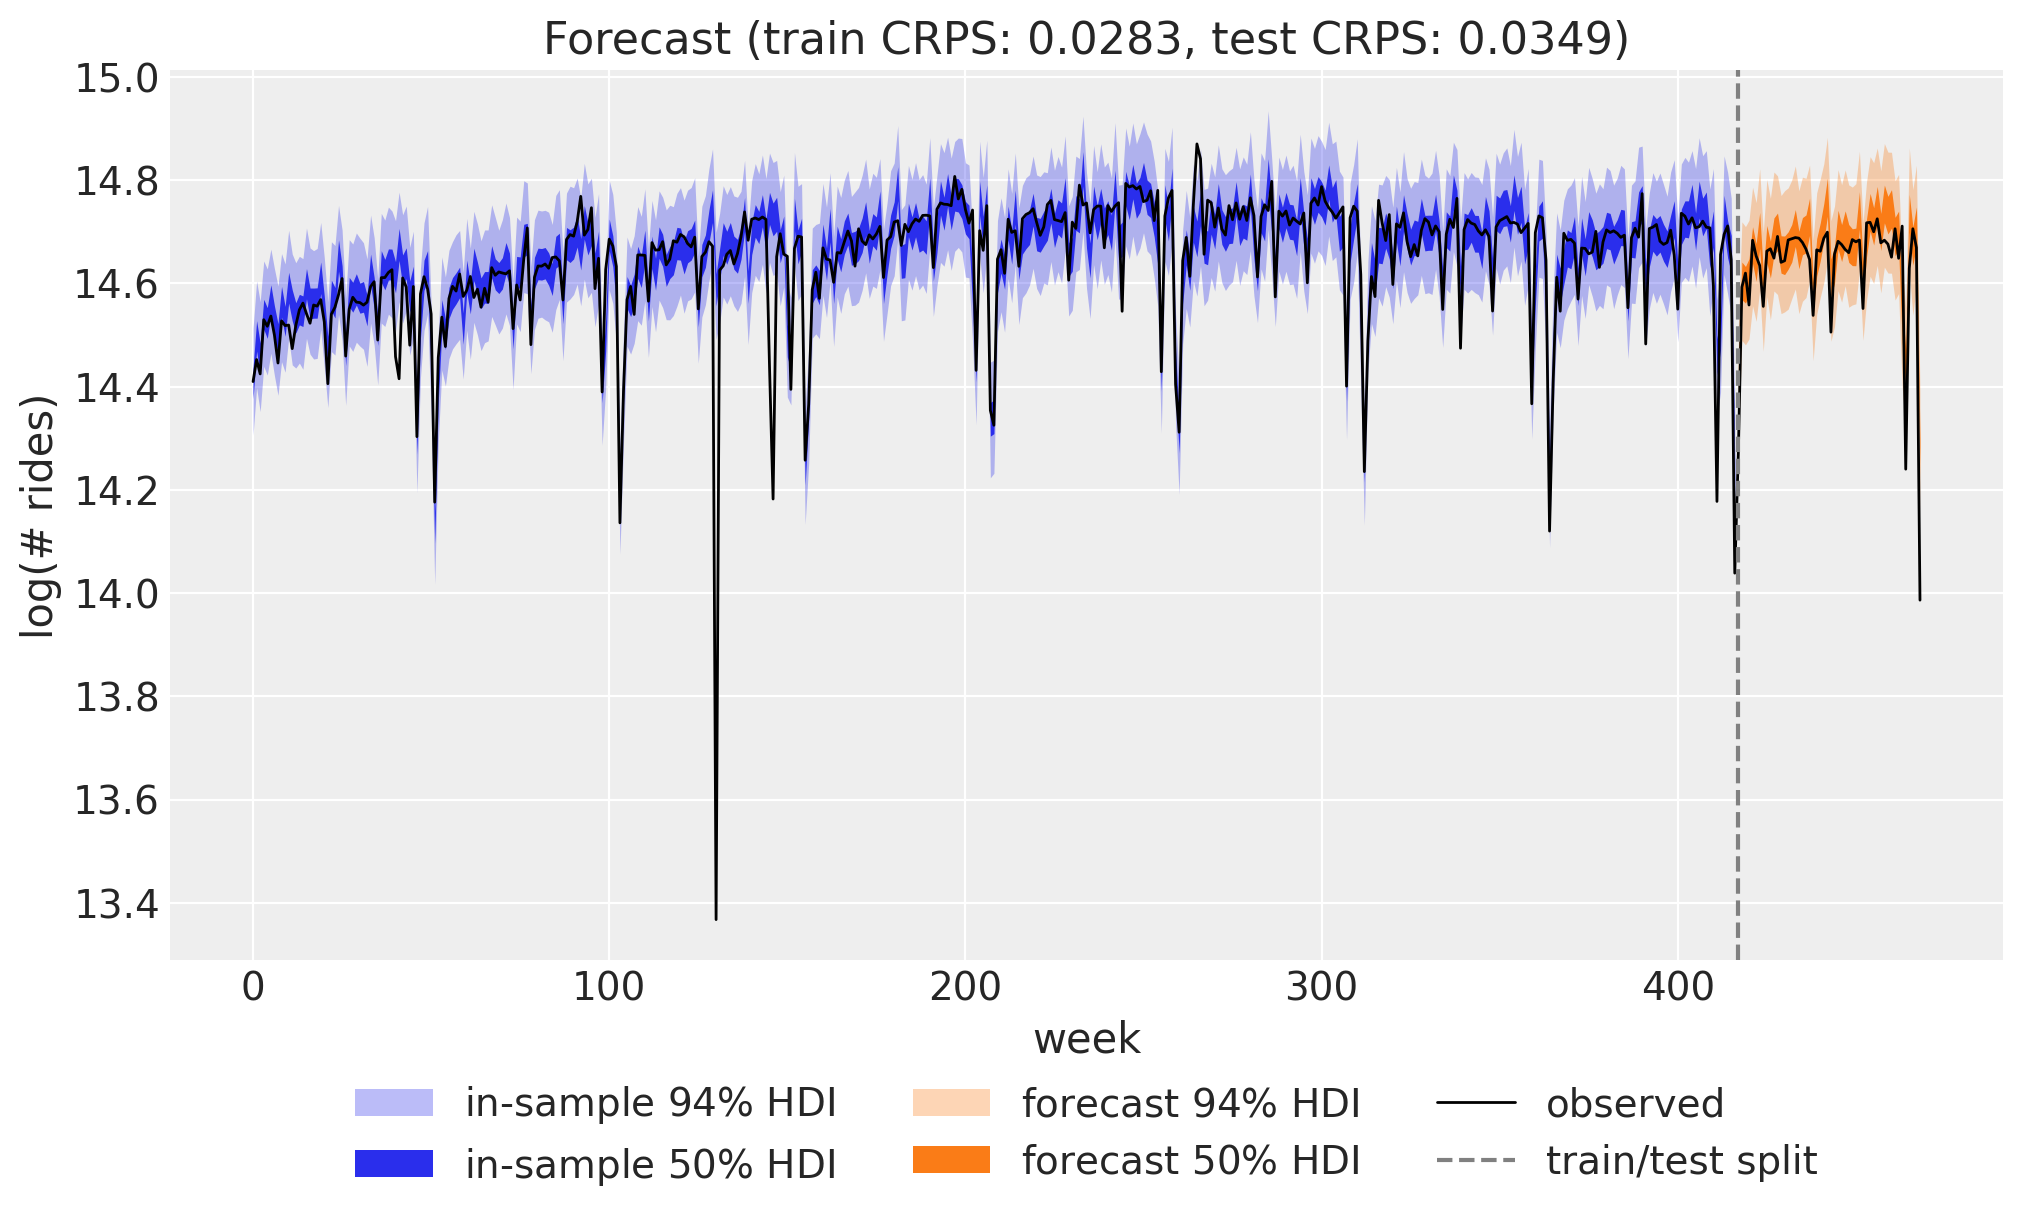

In [10]:
train_obs = train_pp[..., 0]
forecast_obs = forecast[..., 0]

idata_train = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(train_obs)[None]},
        "observed_data": {"obs": np.asarray(y_train[:, 0])},
        "constant_data": {"week": time_train.astype(float)},
    },
    coords={"time": time_train.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
idata_test = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_obs)[None]},
        "observed_data": {"obs": np.asarray(y_test[:, 0])},
        "constant_data": {"week": time_test.astype(float)},
    },
    coords={"time": time_test.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)

band_visuals = {"observed_scatter": False, "pe_line": False}
pc = az.plot_lm(
    idata_train,
    y="obs",
    x="week",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, **band_visuals},
    figure_kwargs={"figsize": (10, 6)},
)
az.plot_lm(
    idata_test,
    y="obs",
    x="week",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, **band_visuals},
)
ax = pc.viz["figure"].item().axes[0]
# ax.collections holds the bands in plotting order: train (0.5, 0.94) then test (0.5, 0.94).
band_train_50, band_train_94, band_test_50, band_test_94 = ax.collections
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
(obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
split_line = ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    ylabel="log(# rides)",
);

## Next steps

This local level model with seasonality is a solid baseline. From here a few directions are natural: add holiday or special-event effects (dummy variables or Gaussian bump functions) for days the smooth seasonal basis cannot capture, run a rolling-origin evaluation with `numpyro_forecast.backtest` to get a more honest picture of generalization, or move to many related series at once. The last of these is the subject of the two companion notebooks, [hierarchical forecasting I](hierarchical_forecasting_1.html) and [II](hierarchical_forecasting_2.html), which generalize this same model to a panel of BART stations. See also Pyro's original [forecasting tutorial](https://pyro.ai/examples/forecasting_i.html).